# Trial Analysis Notebook

사람(`human`)과 매크로(`macro`) trial 데이터를 한 번에 읽고,
요약 통계, 시각화, 상관관계, 간단한 분류 성능까지 확인하는 분석 노트북입니다.

권장 실행 순서:
1. 커널 재시작
2. 위에서 아래로 `Run All`
3. 중간 셀을 건너뛰지 말고 순서대로 실행


## 1. 라이브러리와 기본 설정

- 한글 시각화가 깨지지 않도록 폰트를 먼저 설정합니다.
- 경로는 현재 작업 폴더가 달라도 찾을 수 있게 자동 탐색합니다.


In [17]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")

FONT_CANDIDATES = ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]
for font_name in FONT_CANDIDATES:
    try:
        plt.rcParams["font.family"] = font_name
        break
    except Exception:
        continue

plt.rcParams["axes.unicode_minus"] = False
print("font:", plt.rcParams["font.family"])


font: ['Malgun Gothic']


In [18]:
def find_browser_automation_root(start: Path | None = None) -> Path:
    """현재 작업 위치와 무관하게 browser_automation 루트를 찾는다."""
    base = (start or Path.cwd()).resolve()
    candidates = [base, *base.parents]

    for current in candidates:
        if current.name == "browser_automation" and (current / "collector_api").exists():
            return current

        nested = current / "services" / "ai" / "macro" / "browser_automation"
        if nested.exists() and (nested / "collector_api").exists():
            return nested

    raise FileNotFoundError("browser_automation 루트를 찾지 못했습니다.")


ROOT_DIR = find_browser_automation_root()
ANALYSIS_DIR = ROOT_DIR / "analysis"
TRIAL_DIR = ROOT_DIR / "collector_api" / "data" / "trials"

print("ROOT_DIR:", ROOT_DIR)
print("TRIAL_DIR:", TRIAL_DIR)
print("trial json count:", len(list(TRIAL_DIR.glob("trial_*.json"))))


ROOT_DIR: C:\Users\SSAFY\Desktop\ws\01_main\S14P31A203\services\ai\macro\browser_automation
TRIAL_DIR: C:\Users\SSAFY\Desktop\ws\01_main\S14P31A203\services\ai\macro\browser_automation\collector_api\data\trials
trial json count: 45


## 2. feature 이름 매핑

- 원본 feature 이름은 유지합니다.
- 그래프에는 짧은 한글 이름을 사용해 가독성을 높입니다.


In [19]:
FEATURE_NAME_MAP = {
    "time_to_first_click_ms": "첫 클릭 시간",
    "time_from_element_visible_to_click_ms": "노출 후 클릭",
    "time_from_element_clickable_to_click_ms": "활성 후 클릭",
    "inter_click_interval_ms": "클릭 간격",
    "click_sequence_consistency_score": "순서 일관성",
    "click_position_repeat_rate": "좌표 반복률",
    "click_offset_from_element_center_px": "중심 오차",
    "click_offset_variance_px": "오차 분산",
    "double_click_rate": "더블클릭 비율",
    "misclick_rate": "오클릭 비율",
    "reclick_rate": "재클릭 비율",
    "pre_click_mousemove_count": "클릭 전 이동 수",
    "pre_click_hover_time_ms": "클릭 전 hover",
    "pre_click_scroll_flag": "클릭 전 스크롤",
    "immediate_post_render_click_rate": "즉시 클릭 비율",
    "mouse_total_travel_distance_px": "총 이동 거리",
    "mouse_avg_speed_px_per_ms": "평균 속도",
    "mouse_max_speed_px_per_ms": "최대 속도",
    "mouse_speed_change_mean": "속도 변화",
    "mouse_acceleration_mean": "가속도 변화",
    "mouse_jerk_mean": "저크 평균",
    "mouse_path_straightness_score": "경로 직선성",
    "mouse_path_curvature_mean": "경로 곡률",
    "mouse_direction_change_count": "방향 전환 수",
    "mouse_overshoot_flag": "오버슈트 여부",
    "mouse_hover_dwell_time_ms": "평균 dwell",
    "mouse_stop_segment_count": "정지 구간 수",
    "mousemove_event_rate": "mousemove 빈도",
    "pre_click_mouse_path_pattern_300ms": "300ms 경로 패턴",
    "pre_click_mouse_path_pattern_500ms": "500ms 경로 패턴",
    "inter_element_move_interval_std_ms": "이동 간격 표준편차",
    "edge_or_fixed_point_visit_rate": "고정점 방문률",
}

FEATURE_COLUMNS = list(FEATURE_NAME_MAP.keys())
SHORT_NAME = pd.Series(FEATURE_NAME_MAP)
SHORT_NAME.head()


time_to_first_click_ms                     첫 클릭 시간
time_from_element_visible_to_click_ms      노출 후 클릭
time_from_element_clickable_to_click_ms    활성 후 클릭
inter_click_interval_ms                      클릭 간격
click_sequence_consistency_score            순서 일관성
dtype: object

## 3. trial 데이터 로드

- trial JSON 하나당 한 행으로 펼칩니다.
- `trialLabel`이 있으면 우선 사용합니다.
- 없으면 과거 실험 규칙인 `1~10 = macro`, `11~20 = human`을 보조 규칙으로 사용합니다.


In [20]:
def resolve_label(payload: dict, trial_id: int) -> tuple[int, str] | None:
    stored_label = payload.get("trialLabel") or payload.get("summary", {}).get("trialLabel")

    if stored_label == "macro":
        return 1, "macro"
    if stored_label == "human":
        return 0, "human"
    if 1 <= trial_id <= 10:
        return 1, "macro"
    if 11 <= trial_id <= 20:
        return 0, "human"
    return None


def load_trial_frame(trial_dir: Path) -> tuple[pd.DataFrame, list[int]]:
    rows: list[dict] = []
    skipped: list[int] = []

    for path in sorted(trial_dir.glob("trial_*.json")):
        payload = json.loads(path.read_text(encoding="utf-8"))
        trial_id = int(payload["trialId"])
        resolved = resolve_label(payload, trial_id)

        if resolved is None:
            skipped.append(trial_id)
            continue

        label, label_name = resolved
        summary = payload.get("summary", {})
        metrics = payload.get("metrics", {})

        row = {
            "trial_id": trial_id,
            "label": label,
            "label_name": label_name,
            "event_count": len(payload.get("eventRows", [])),
            "window_count": len(payload.get("windowRows", [])),
        }
        row.update(summary)
        row.update(metrics)
        rows.append(row)

    if not rows:
        empty = pd.DataFrame(columns=["trial_id", "label", "label_name", "event_count", "window_count"])
        return empty, skipped

    frame = pd.DataFrame(rows).sort_values("trial_id").reset_index(drop=True)
    return frame, skipped


df, skipped_trials = load_trial_frame(TRIAL_DIR)
print("loaded labeled trials:", len(df))
print("skipped trials:", skipped_trials if skipped_trials else "없음")

if df.empty:
    raise ValueError("라벨링된 trial이 없습니다. trialLabel 또는 trial 번호 범위를 확인하세요.")

df.head()


loaded labeled trials: 45
skipped trials: 없음


,trial_id,label,label_name,event_count,window_count,stage,durationMs,clickCount,eventCount,windowCount,...,mouse_direction_change_count,mouse_overshoot_flag,mouse_hover_dwell_time_ms,mouse_stop_segment_count,mousemove_event_rate,pre_click_mouse_path_pattern_300ms,pre_click_mouse_path_pattern_500ms,inter_element_move_interval_std_ms,edge_or_fixed_point_visit_rate,trialLabel
0,1,1,macro,10,6,confirmed,1450.8,5,10,6,...,2,0,246.50,3,3.446374,668.7px | straight 1.00,668.7px | straight 1.00,87.574436,0.0,NaN
1,2,1,macro,10,6,confirmed,1416.7,5,10,6,...,2,0,239.28,3,3.529329,668.7px | straight 1.00,715.7px | straight 1.00,79.518268,0.0,NaN
2,3,1,macro,10,6,confirmed,1436.6,5,10,6,...,2,0,240.88,3,3.480440,668.7px | straight 1.00,715.7px | straight 1.00,86.465437,0.0,NaN
3,4,1,macro,10,6,confirmed,1466.9,5,10,6,...,2,0,245.92,3,3.408549,668.7px | straight 1.00,715.7px | straight 1.00,82.112271,0.0,NaN
4,5,1,macro,10,6,confirmed,1426.5,5,10,6,...,2,0,238.46,3,3.505082,668.7px | straight 1.00,715.7px | straight 1.00,82.994608,0.0,NaN


## 4. 기본 점검

- 클래스 개수와 기본 메타데이터를 먼저 확인합니다.
- 이 셀에서 데이터가 이상하면 뒤 시각화보다 먼저 저장 구조를 확인하는 편이 좋습니다.


In [21]:
display(df[["trial_id", "label_name", "event_count", "window_count"]].head(10))
display(df["label_name"].value_counts().rename("trial_count").to_frame())
display(df[["event_count", "window_count"]].describe().T)


,trial_id,label_name,event_count,window_count
0,1,macro,10,6
1,2,macro,10,6
2,3,macro,10,6
3,4,macro,10,6
4,5,macro,10,6
5,6,macro,10,5
6,7,macro,10,6
7,8,macro,10,6
8,9,macro,10,5
9,10,macro,10,5


,trial_count
label_name,
macro,31
human,14


,count,mean,std,min,25%,50%,75%,max
event_count,45.0,140.177778,162.118404,10.0,48.0,48.0,293.0,539.0
window_count,45.0,12.177778,7.895018,5.0,6.0,11.0,18.0,45.0


## 5. 모델 입력용 feature 프레임 만들기

- 실제로 존재하는 feature만 골라 사용합니다.
- 결측치는 이후 모델 파이프라인에서 중앙값으로 보정합니다.


In [22]:
available_features = [feature for feature in FEATURE_COLUMNS if feature in df.columns]
missing_features = [feature for feature in FEATURE_COLUMNS if feature not in df.columns]

print("available feature count:", len(available_features))
print("missing feature count:", len(missing_features))
if missing_features:
    print("missing sample:", missing_features[:10])

X = df[available_features].apply(pd.to_numeric, errors="coerce")
y = df["label"]

display(X.head())


available feature count: 32
missing feature count: 0


,time_to_first_click_ms,time_from_element_visible_to_click_ms,time_from_element_clickable_to_click_ms,inter_click_interval_ms,click_sequence_consistency_score,click_position_repeat_rate,click_offset_from_element_center_px,click_offset_variance_px,double_click_rate,misclick_rate,...,mouse_path_curvature_mean,mouse_direction_change_count,mouse_overshoot_flag,mouse_hover_dwell_time_ms,mouse_stop_segment_count,mousemove_event_rate,pre_click_mouse_path_pattern_300ms,pre_click_mouse_path_pattern_500ms,inter_element_move_interval_std_ms,edge_or_fixed_point_visit_rate
0,219.4,428.62,428.62,307.775,1.0,0.0,0.783835,0.02686,0.8,0.0,...,0.022442,2,0,246.50,3,3.446374,NaN,NaN,87.574436,0.0
1,221.1,421.10,421.10,298.800,1.0,0.0,0.783835,0.02686,0.8,0.0,...,0.022442,2,0,239.28,3,3.529329,NaN,NaN,79.518268,0.0
2,232.9,426.60,426.60,300.825,1.0,0.0,0.783835,0.02686,0.8,0.0,...,0.022442,2,0,240.88,3,3.480440,NaN,NaN,86.465437,0.0
3,238.5,433.00,433.00,307.000,1.0,0.0,0.783835,0.02686,0.8,0.0,...,0.022442,2,0,245.92,3,3.408549,NaN,NaN,82.112271,0.0
4,235.3,417.80,417.80,297.700,1.0,0.0,0.783835,0.02686,0.8,0.0,...,0.022442,2,0,238.46,3,3.505082,NaN,NaN,82.994608,0.0


## 6. feature 평균 비교

- 사람과 매크로 평균 차이를 빠르게 보는 표입니다.
- 절대값 차이가 큰 feature를 먼저 보는 것이 해석에 편합니다.


In [23]:
mean_table = (
    df.groupby("label_name")[available_features]
    .mean(numeric_only=True)
    .T
    .rename_axis("feature")
    .reset_index()
)

if {"macro", "human"}.issubset(mean_table.columns):
    mean_table["mean_diff_abs"] = (mean_table["macro"] - mean_table["human"]).abs()
    mean_table = mean_table.sort_values("mean_diff_abs", ascending=False)

mean_table["feature_ko"] = mean_table["feature"].map(FEATURE_NAME_MAP).fillna(mean_table["feature"])
display(mean_table[["feature_ko", "feature", *[col for col in ["macro", "human", "mean_diff_abs"] if col in mean_table.columns]]].head(15))


label_name,feature_ko,feature,macro,human,mean_diff_abs
0,첫 클릭 시간,time_to_first_click_ms,323.274194,1652.057143,1328.782949
7,오차 분산,click_offset_variance_px,0.031944,1063.045456,1063.013513
15,총 이동 거리,mouse_total_travel_distance_px,1572.307743,2586.732796,1014.425054
2,활성 후 클릭,time_from_element_clickable_to_click_ms,571.310108,1462.991071,891.680964
1,노출 후 클릭,time_from_element_visible_to_click_ms,571.310108,1462.991071,891.680964
3,클릭 간격,inter_click_interval_ms,391.973548,639.989473,248.015924
28,이동 간격 표준편차,inter_element_move_interval_std_ms,143.317585,303.147106,159.829521
12,클릭 전 hover,pre_click_hover_time_ms,91.959140,225.532072,133.572932
23,방향 전환 수,mouse_direction_change_count,5.741935,61.571429,55.829493
25,평균 dwell,mouse_hover_dwell_time_ms,196.735943,143.654172,53.081771


## 7. 상관관계 기반 상위 feature

- 이진 라벨(`macro=1`, `human=0`)과 각 feature의 상관계수를 계산합니다.
- 절대값 기준으로 큰 feature일수록 분리력이 강할 가능성이 큽니다.


In [24]:
corr_rows = []
for feature in available_features:
    series = pd.to_numeric(df[feature], errors="coerce")
    if series.notna().sum() < 3:
        continue
    corr = series.corr(df["label"])
    if pd.isna(corr):
        continue
    corr_rows.append(
        {
            "feature": feature,
            "feature_ko": FEATURE_NAME_MAP.get(feature, feature),
            "correlation": corr,
            "abs_correlation": abs(corr),
        }
    )

corr_df = pd.DataFrame(corr_rows).sort_values("abs_correlation", ascending=False).reset_index(drop=True)
top_corr_df = corr_df.head(12)
display(top_corr_df)


c:\Users\SSAFY\.conda\envs\computer_vision\lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\SSAFY\.conda\envs\computer_vision\lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,feature,feature_ko,correlation,abs_correlation
0,click_offset_from_element_center_px,중심 오차,-0.948257,0.948257
1,mouse_direction_change_count,방향 전환 수,-0.946204,0.946204
2,mousemove_event_rate,mousemove 빈도,-0.917235,0.917235
3,pre_click_mousemove_count,클릭 전 이동 수,-0.908955,0.908955
4,mouse_stop_segment_count,정지 구간 수,-0.831713,0.831713
5,mouse_speed_change_mean,속도 변화,0.800699,0.800699
6,time_to_first_click_ms,첫 클릭 시간,-0.786553,0.786553
7,immediate_post_render_click_rate,즉시 클릭 비율,0.783121,0.783121
8,time_from_element_visible_to_click_ms,노출 후 클릭,-0.778078,0.778078
9,time_from_element_clickable_to_click_ms,활성 후 클릭,-0.778078,0.778078


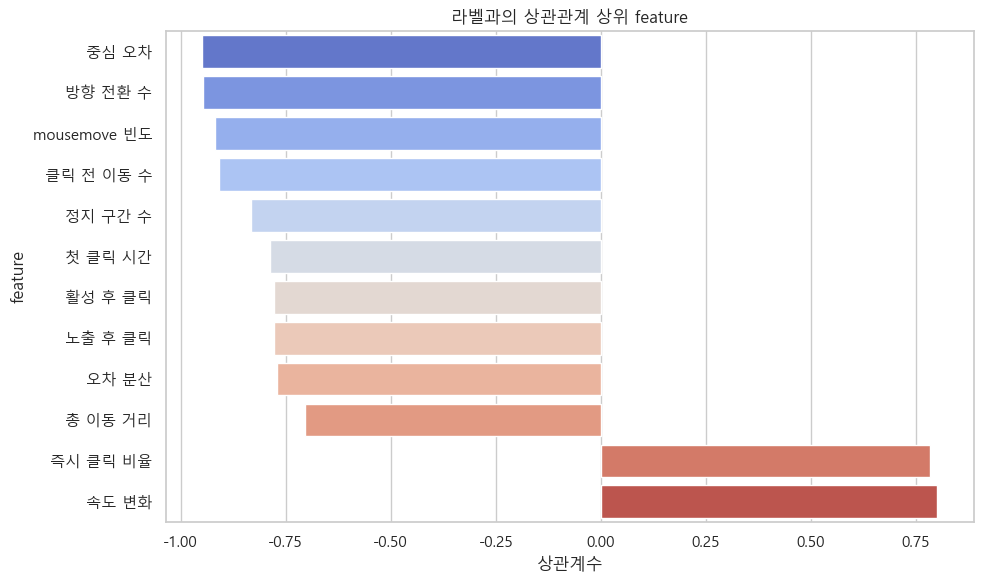

In [25]:
plt.figure(figsize=(10, 6))
plot_df = top_corr_df.sort_values("correlation")
sns.barplot(data=plot_df, x="correlation", y="feature_ko", hue="feature_ko", palette="coolwarm", legend=False)
plt.title("라벨과의 상관관계 상위 feature")
plt.xlabel("상관계수")
plt.ylabel("feature")
plt.tight_layout()
plt.show()


## 8. 대표 feature 분포 시각화

- 상관관계 상위 feature 중 최대 6개를 골라 boxplot으로 비교합니다.
- 필요하면 이 셀에서 feature 수를 더 줄여도 됩니다.


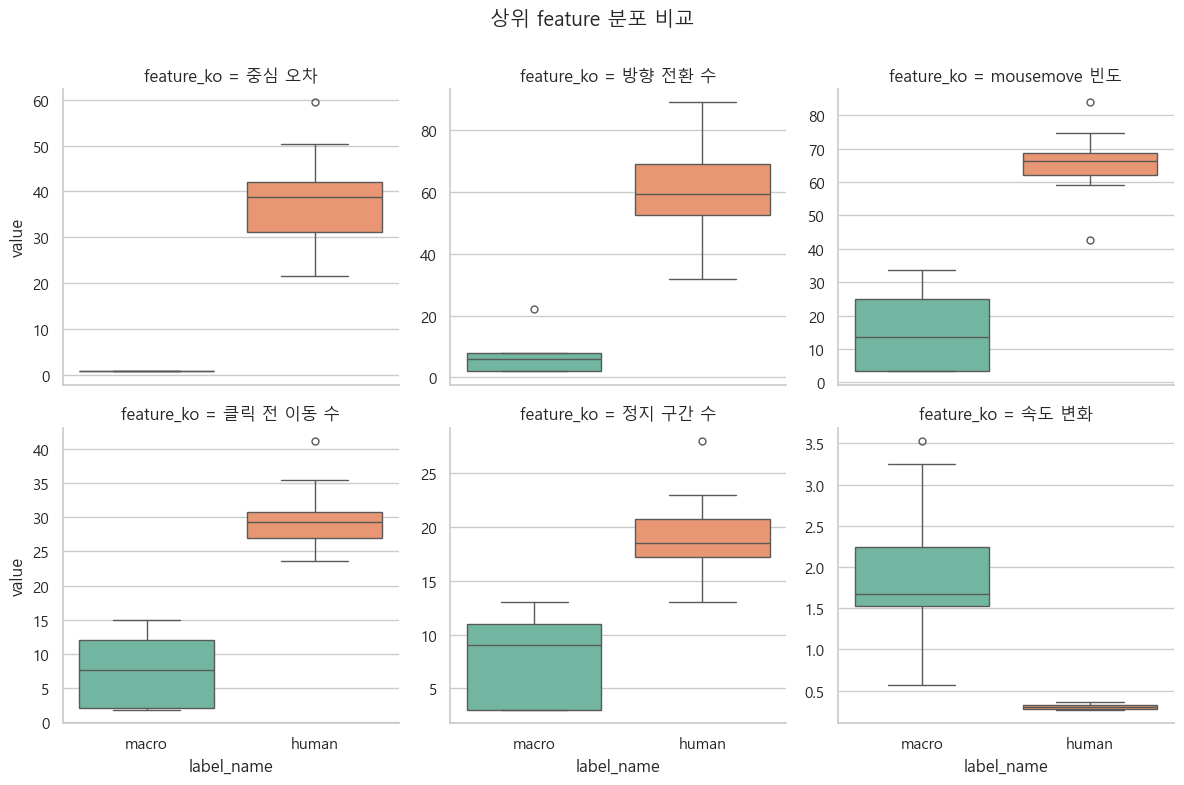

In [26]:
selected_features = top_corr_df["feature"].head(6).tolist()
long_df = df[["label_name", *selected_features]].melt(id_vars="label_name", var_name="feature", value_name="value")
long_df["feature_ko"] = long_df["feature"].map(FEATURE_NAME_MAP).fillna(long_df["feature"])

g = sns.catplot(
    data=long_df,
    x="label_name",
    y="value",
    hue="label_name",
    col="feature_ko",
    kind="box",
    col_wrap=3,
    sharey=False,
    height=4,
    palette="Set2",
    legend=False,
)
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle("상위 feature 분포 비교")
plt.show()


## 9. feature 상관행렬

- 상위 feature끼리 서로 비슷한 신호인지 확인합니다.
- 강하게 중복되는 feature가 많으면 나중에 차원 축소나 feature 선택에 참고할 수 있습니다.


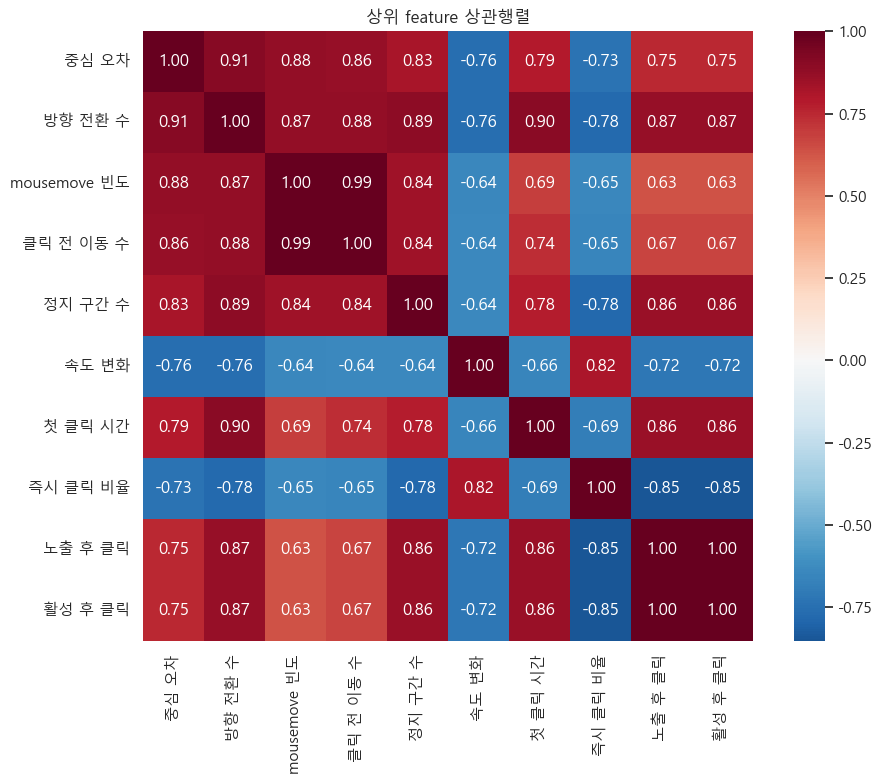

In [27]:
heatmap_features = top_corr_df["feature"].head(10).tolist()
heatmap_frame = X[heatmap_features].copy()
heatmap_frame.columns = [FEATURE_NAME_MAP.get(col, col) for col in heatmap_frame.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_frame.corr(), annot=True, cmap="RdBu_r", center=0, fmt=".2f", square=True)
plt.title("상위 feature 상관행렬")
plt.tight_layout()
plt.show()


## 10. 간단한 머신러닝 기준선 평가

- 표본 수가 적으므로 `Leave-One-Out`으로 평가합니다.
- `LogisticRegression`과 `RandomForest` 두 개만 가볍게 비교합니다.


In [28]:
loo = LeaveOneOut()

models = {
    "logistic": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=5000, random_state=42)),
        ]
    ),
    "random_forest": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=300,
                    max_depth=None,
                    min_samples_leaf=1,
                    random_state=42,
                ),
            ),
        ]
    ),
}

eval_rows = []
prediction_store: dict[str, list[int]] = {}

for model_name, model in models.items():
    preds = []
    truths = []

    for train_idx, test_idx in loo.split(X):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model.fit(X_train, y_train)
        pred = int(model.predict(X_test)[0])

        preds.append(pred)
        truths.append(int(y_test.iloc[0]))

    prediction_store[model_name] = preds
    eval_rows.append({"model": model_name, "accuracy": accuracy_score(truths, preds)})

eval_df = pd.DataFrame(eval_rows).sort_values("accuracy", ascending=False).reset_index(drop=True)
display(eval_df)


c:\Users\SSAFY\.conda\envs\computer_vision\lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['pre_click_mouse_path_pattern_300ms' 'pre_click_mouse_path_pattern_500ms']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\SSAFY\.conda\envs\computer_vision\lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['pre_click_mouse_path_pattern_300ms' 'pre_click_mouse_path_pattern_500ms']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\SSAFY\.conda\envs\computer_vision\lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['pre_click_mouse_path_pattern_300ms' 'pre_click_mouse_path_pattern_500ms']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\SSAFY\.conda\envs\c

,model,accuracy
0,logistic,1.0
1,random_forest,1.0


best model: logistic
              precision    recall  f1-score   support

       human       1.00      1.00      1.00        14
       macro       1.00      1.00      1.00        31

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



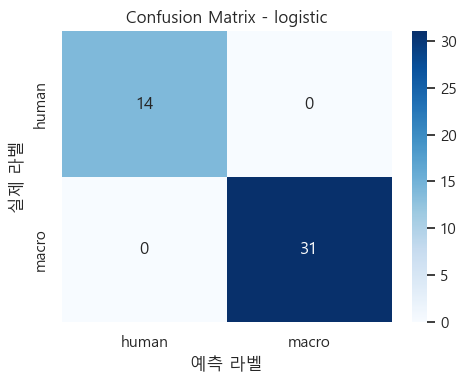

In [29]:
best_model_name = eval_df.iloc[0]["model"]
best_preds = prediction_store[best_model_name]

print("best model:", best_model_name)
print(classification_report(y, best_preds, target_names=["human", "macro"]))

cm = confusion_matrix(y, best_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["human", "macro"], yticklabels=["human", "macro"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("예측 라벨")
plt.ylabel("실제 라벨")
plt.tight_layout()
plt.show()


## 11. 해석용 importance 확인

- 선형 모델은 계수 절대값으로,
- 랜덤 포레스트는 feature importance로 확인합니다.
- 둘 다 해석용 참고 지표로만 보고, 표본 수가 적다는 점은 항상 같이 봐야 합니다.


In [ ]:
# logistic_full = models["logistic"].fit(X, y)
# rf_full = models["random_forest"].fit(X, y)

# logistic_coef = pd.DataFrame(
#     {
#         "feature": available_features,
#         "feature_ko": [FEATURE_NAME_MAP.get(feature, feature) for feature in available_features],
#         "importance": np.abs(logistic_full.named_steps["model"].coef_[0]),
#     }
# ).sort_values("importance", ascending=False)

# rf_importance = pd.DataFrame(
#     {
#         "feature": available_features,
#         "feature_ko": [FEATURE_NAME_MAP.get(feature, feature) for feature in available_features],
#         "importance": rf_full.named_steps["model"].feature_importances_,
#     }
# ).sort_values("importance", ascending=False)

# display(logistic_coef.head(10))
# display(rf_importance.head(10))


c:\Users\SSAFY\.conda\envs\computer_vision\lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['pre_click_mouse_path_pattern_300ms' 'pre_click_mouse_path_pattern_500ms']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\SSAFY\.conda\envs\computer_vision\lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['pre_click_mouse_path_pattern_300ms' 'pre_click_mouse_path_pattern_500ms']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


ValueError: All arrays must be of the same length

In [ ]:
# fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# sns.barplot(
#     data=logistic_coef.head(10).sort_values("importance"),
#     x="importance",
#     y="feature_ko",
#     hue="feature_ko",
#     palette="crest",
#     legend=False,
#     ax=axes[0],
# )
# axes[0].set_title("LogisticRegression 중요도")
# axes[0].set_xlabel("|coefficient|")
# axes[0].set_ylabel("feature")

# sns.barplot(
#     data=rf_importance.head(10).sort_values("importance"),
#     x="importance",
#     y="feature_ko",
#     hue="feature_ko",
#     palette="flare",
#     legend=False,
#     ax=axes[1],
# )
# axes[1].set_title("RandomForest 중요도")
# axes[1].set_xlabel("importance")
# axes[1].set_ylabel("feature")

# plt.tight_layout()
# plt.show()


## 12. 다음 단계 메모

- trial 수가 늘어나면 `window_rows.jsonl` 기반 시계열 분석 노트북을 분리하는 것이 좋습니다.
- 현재 결과가 잘 나와도 표본 수가 적으므로, 실제 서비스 적용 전에는 더 다양한 사람 행동과 매크로 설정을 수집해야 합니다.
- feature 해석 기준은 `analysis/FEATURE_REFERENCE_KO.md`를 같이 참고하면 편합니다.
